# Baseline Model

## 1. Import data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, balanced_accuracy_score,
                             ConfusionMatrixDisplay)

sns.set_style("whitegrid")
RANDOM_STATE = 42
LABELS = ["Negative", "Neutral", "Positive"]

df = pd.read_csv("../data/processed/amazon_reviews_clean.csv", low_memory=False)
print("Shape:", df.shape)
df.head(3)

Shape: (34626, 9)


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,0.0,True,Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,0.0,True,Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,0.0,True,Positive


### 1.1 Load data from **functions.py**

In [6]:
%load_ext autoreload
%autoreload 2

from functions import evaluate, LABELS, RANDOM_STATE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.2 call the functions to create a comparison table at the end of all models' notebooks

In [10]:
from functions import evaluate, LABELS, RANDOM_STATE

scores = []          # ← here

### 1.3 the following function goes at the end of the notebook's model to create the comparison table
pd.DataFrame(scores).set_index("model").sort_values("f1_macro", ascending=False).round(4)

## 2. Train / validation / test split

In [7]:
df["text_full"] = (df["reviews.title"].fillna("") + ". " + df["reviews.text"]).str.strip()

df = df.dropna(subset=["text_full", "sentiment"])
assert df["sentiment"].isin(LABELS).all(), "Unexpected sentiment label"

print("Rows used:", len(df))
df["sentiment"].value_counts()[LABELS]

Rows used: 34626


sentiment
Negative      812
Neutral      1499
Positive    32315
Name: count, dtype: int64

In [8]:
X = df["text_full"]
y = df["sentiment"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    pct = (yy.value_counts(normalize=True) * 100).round(1)
    print(f"{name:>5}: {len(yy):>6} rows | " +
          " ".join(f"{l} {pct[l]}%" for l in LABELS))

train:  24238 rows | Negative 2.3% Neutral 4.3% Positive 93.3%
  val:   5194 rows | Negative 2.3% Neutral 4.3% Positive 93.3%
 test:   5194 rows | Negative 2.3% Neutral 4.3% Positive 93.3%


## 3. Baseline 

### 3.1 Dummy Classifier

=== Dummy (most frequent) ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       121
     Neutral       0.00      0.00      0.00       225
    Positive       0.93      1.00      0.97      4848

    accuracy                           0.93      5194
   macro avg       0.31      0.33      0.32      5194
weighted avg       0.87      0.93      0.90      5194



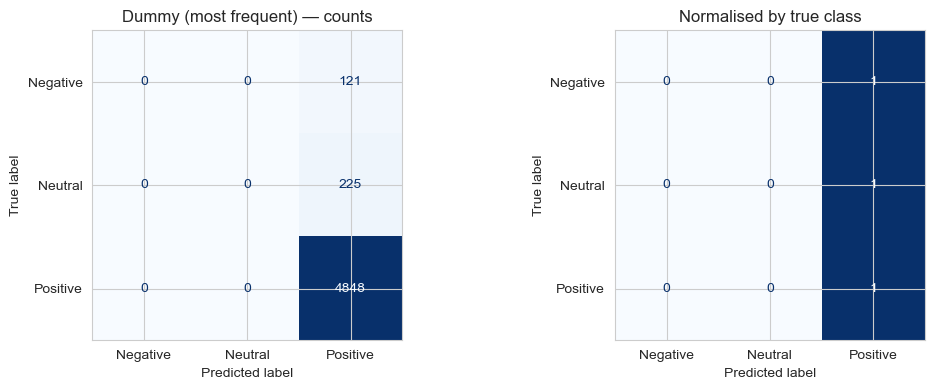

In [12]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
scores.append(evaluate(y_val, dummy.predict(X_val), "Dummy (most frequent)"))

## 3.2 Baseline
    - TF-IDF
    - Logistical Regression (balanced weights)

=== TF-IDF + LogReg (balanced) ===
              precision    recall  f1-score   support

    Negative       0.37      0.54      0.44       121
     Neutral       0.23      0.44      0.30       225
    Positive       0.97      0.92      0.95      4848

    accuracy                           0.89      5194
   macro avg       0.53      0.63      0.56      5194
weighted avg       0.93      0.89      0.91      5194



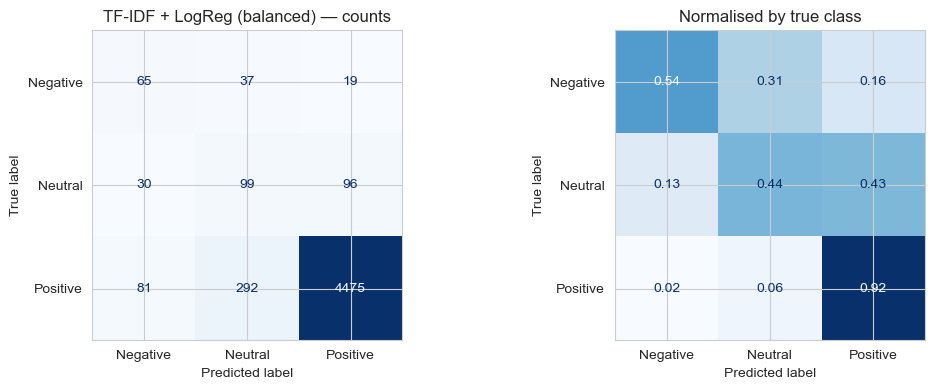

In [11]:
logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
        strip_accents="unicode",
        stop_words="english")),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
scores.append(evaluate(y_val, logreg.predict(X_val), "TF-IDF + LogReg (balanced)"))

## 4. Comparing models

Comparing Dummy with TF-IDF + Log Reg table:

    - Dummy high accuracy bc not taking into consideration negative or neutral, so it fails on the F1 macro
    
    - TF-IDF + logReg: the model to beat! F1 macro **0.56**

,accuracy,f1_macro,f1_negative,f1_neutral,f1_positive
model,,,,,
TF-IDF + LogReg (balanced),0.8931,0.5631,0.4377,0.3032,0.9483
Dummy (most frequent),0.9334,0.3218,0.0000,0.0000,0.9655


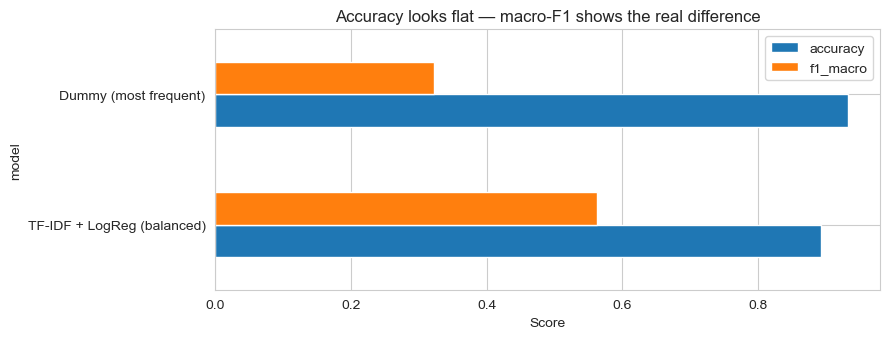

In [13]:
cmp = (pd.DataFrame(scores)
         .set_index("model")
         .sort_values("f1_macro", ascending=False)
         .round(4))

display(cmp[["accuracy", "f1_macro", "f1_negative", "f1_neutral", "f1_positive"]])

ax = cmp[["accuracy", "f1_macro"]].plot(kind="barh", figsize=(9, 3.5))
ax.set_xlabel("Score")
ax.set_title("Accuracy looks flat — macro-F1 shows the real difference")
plt.tight_layout(); plt.show()

## 5. Final Evaluation on Test Set

=== FINAL BASELINE — test set ===
              precision    recall  f1-score   support

    Negative       0.37      0.57      0.44       122
     Neutral       0.22      0.44      0.30       225
    Positive       0.98      0.92      0.95      4847

    accuracy                           0.89      5194
   macro avg       0.52      0.64      0.56      5194
weighted avg       0.93      0.89      0.91      5194



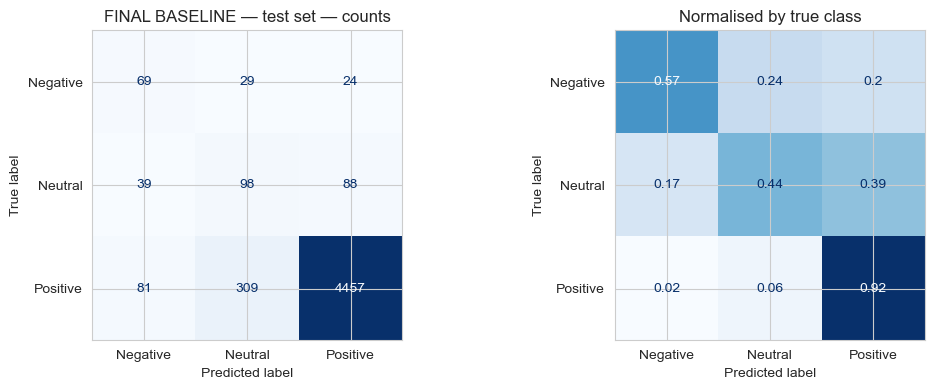

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,FINAL BASELINE — test set,0.8903,0.6402,0.5623,0.9067,0.4437,0.2965,0.9467


In [14]:
test_results = evaluate(y_test, logreg.predict(X_test),
                        "FINAL BASELINE — test set")

pd.DataFrame([test_results]).round(4)